In [2]:
import pandas as pd
import matplotlib.pyplot as plt 

Intercept: -71.78
Coefficient: 0.93
Mean Squared Error: 83.24
R-squared: 0.6982


c:\Users\Dell\Desktop\MACHINE_LEARNING_FOUNDATION\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


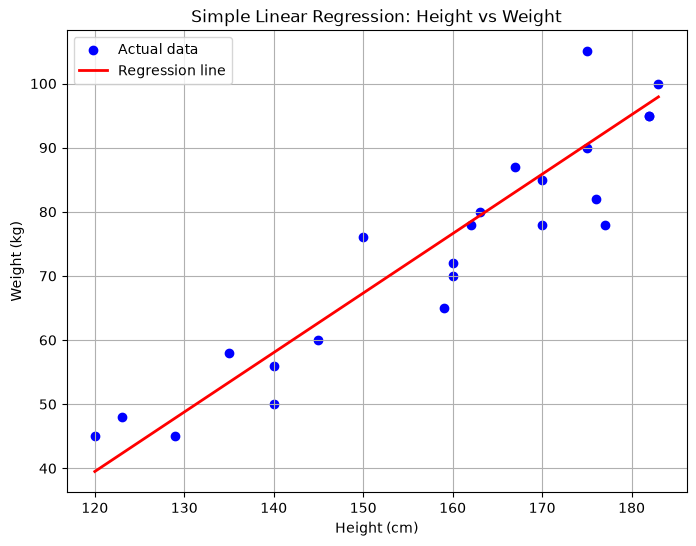

    Height  Actual Weight  Predicted Weight
0      120             45         39.502835
8      182             95         96.997407
9      170             78         85.869425
15     177             78         92.360748
17     159             65         75.668775


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Load data
file_path = "height-weight.csv"
df = pd.read_csv(file_path)

df.head()

# Prepare features and target
X = df[["Height"]]
y = df["Weight"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficient: {model.coef_[0]:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.4f}")

# Plot the dataset and the regression line
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color="blue", label="Actual data")
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_range = model.predict(X_range)
plt.plot(X_range, y_range, color="red", linewidth=2, label="Regression line")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Simple Linear Regression: Height vs Weight")
plt.legend()
plt.grid(True)
plt.show()

# Compare predicted vs actual values for the test set
comparison = pd.DataFrame({
    "Height": X_test["Height"],
    "Actual Weight": y_test,
    "Predicted Weight": y_pred,
})
print(comparison.sort_index())